In [79]:
import numpy 
import numba
import numpy as np
import xarray as xr
import netCDF4 as nc
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pystormtracker as pst

In [80]:
tracker = pst.HodgesTracker()

In [81]:
file_loc_01020304 = "f19a177154e1f391965054b2bed72f43.nc"

data_anatol = xr.open_dataset(file_loc_01020304)

In [82]:
data_anatol

<xarray.Dataset> Size: 133MB
Dimensions:         (valid_time: 16, pressure_level: 1, latitude: 721,
                     longitude: 1440)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 128B 1999-12-02 ... 1999-12-0...
    expver          (valid_time) <U4 256B ...
  * pressure_level  (pressure_level) float64 8B 850.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number          int64 8B ...
Data variables:
    u               (valid_time, pressure_level, latitude, longitude) float32 66MB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 66MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-15T13:55 GRIB to CDM+CF via cfgrib-0.9.1...

In [83]:
data_anatol['latitude'].values


array([ 90.  ,  89.75,  89.5 ,  89.25,  89.  ,  88.75,  88.5 ,  88.25,
        88.  ,  87.75,  87.5 ,  87.25,  87.  ,  86.75,  86.5 ,  86.25,
        86.  ,  85.75,  85.5 ,  85.25,  85.  ,  84.75,  84.5 ,  84.25,
        84.  ,  83.75,  83.5 ,  83.25,  83.  ,  82.75,  82.5 ,  82.25,
        82.  ,  81.75,  81.5 ,  81.25,  81.  ,  80.75,  80.5 ,  80.25,
        80.  ,  79.75,  79.5 ,  79.25,  79.  ,  78.75,  78.5 ,  78.25,
        78.  ,  77.75,  77.5 ,  77.25,  77.  ,  76.75,  76.5 ,  76.25,
        76.  ,  75.75,  75.5 ,  75.25,  75.  ,  74.75,  74.5 ,  74.25,
        74.  ,  73.75,  73.5 ,  73.25,  73.  ,  72.75,  72.5 ,  72.25,
        72.  ,  71.75,  71.5 ,  71.25,  71.  ,  70.75,  70.5 ,  70.25,
        70.  ,  69.75,  69.5 ,  69.25,  69.  ,  68.75,  68.5 ,  68.25,
        68.  ,  67.75,  67.5 ,  67.25,  67.  ,  66.75,  66.5 ,  66.25,
        66.  ,  65.75,  65.5 ,  65.25,  65.  ,  64.75,  64.5 ,  64.25,
        64.  ,  63.75,  63.5 ,  63.25,  63.  ,  62.75,  62.5 ,  62.25,
      

In [84]:
pst.preprocessing.kinematics.compute_vorticity_divergence?

Signature:
pst.preprocessing.kinematics.compute_vorticity_divergence(
    u: 'xr.DataArray | NDArray[np.float64]',
    v: 'xr.DataArray | NDArray[np.float64]',
    *,
    R: 'float' = 6371220.0,
    lmax: 'int | None' = None,
    geometry: 'str' = 'CC',
    nthreads: 'int' = 0,
    lat_reverse: 'bool' = False,
    backend: 'Backend' = 'serial',
) -> 'tuple[xr.DataArray | NDArray[np.float64], xr.DataArray | NDArray[np.float64]]'
Docstring:
Computes spatial divergence and relative vorticity from u and v wind components.
Accepts either a pair of xarray DataArrays or a pair of 2D NumPy arrays.

Args:
    u: Zonal wind component (DataArray or 2D NumPy array).
    v: Meridional wind component (DataArray or 2D NumPy array).
    R: Planetary radius in meters. Default is R_EARTH_M.
    lmax: Maximum spherical harmonic degree.
    geometry: Grid geometry ('CC', 'DH', etc.). Default 'CC'.
    nthreads: Number of threads.
    lat_reverse: If True, assume latitude is North to South (NumPy only).
  

In [85]:
div, vort = pst.preprocessing.kinematics.compute_vorticity_divergence(data_anatol['u'], data_anatol['v'])

In [86]:
vort

<xarray.DataArray 'relative_vorticity' (valid_time: 16, pressure_level: 1,
                                        latitude: 721, longitude: 1440)> Size: 66MB
array([[[[ 1.9602574e-05,  1.9602574e-05,  1.9602574e-05, ...,
           1.9602574e-05,  1.9602574e-05,  1.9602574e-05],
         [-3.9773434e-04, -3.9748411e-04, -3.9722299e-04, ...,
          -3.9841977e-04, -3.9820219e-04, -3.9797369e-04],
         [-1.2706438e-04, -1.2700674e-04, -1.2694340e-04, ...,
          -1.2720325e-04, -1.2716262e-04, -1.2711635e-04],
         ...,
         [ 6.6792403e-05,  6.6952685e-05,  6.7112378e-05, ...,
           6.6308065e-05,  6.6470086e-05,  6.6631532e-05],
         [ 4.9804634e-04,  4.9906579e-04,  5.0007703e-04, ...,
           4.9493910e-04,  4.9598300e-04,  4.9701874e-04],
         [-1.7005186e-05, -1.7005186e-05, -1.7005186e-05, ...,
          -1.7005186e-05, -1.7005186e-05, -1.7005186e-05]]],


       [[[ 2.3893559e-05,  2.3893559e-05,  2.3893559e-05, ...,
           2.3893559e-05,  2.3893559e-05,  2.3893559e-05],
         [-4.2005358e-04, -4.1989013e-04, -4.1971539e-04, ...,
          -4.2047611e-04, -4.2034659e-04, -4.2020573e-04],
         [-1.2959192e-04, -1.2947540e-04, -1.2935327e-04, ...,
...
         [ 5.7369511e-04,  5.7308358e-04,  5.7245756e-04, ...,
           5.7544257e-04,  5.7487463e-04,  5.7429215e-04],
         [-2.0044499e-05, -2.0044499e-05, -2.0044499e-05, ...,
          -2.0044499e-05, -2.0044499e-05, -2.0044499e-05]]],


       [[[-3.0955357e-06, -3.0955357e-06, -3.0955357e-06, ...,
          -3.0955357e-06, -3.0955357e-06, -3.0955357e-06],
         [ 2.9888813e-04,  3.0030814e-04,  3.0172640e-04, ...,
           2.9461799e-04,  2.9604306e-04,  2.9746644e-04],
         [-1.7557037e-05, -1.7580705e-05, -1.7598963e-05, ...,
          -1.7454387e-05, -1.7493796e-05, -1.7528040e-05],
         ...,
         [ 1.4022007e-04,  1.3969160e-04,  1.3916020e-04, ...,
           1.4178734e-04,  1.4126801e-04,  1.4074557e-04],
         [ 5.8980164e-04,  5.8820751e-04,  5.8660062e-04, ...,
           5.9450750e-04,  5.9295166e-04,  5.9138302e-04],
         [ 2.2176928e-05,  2.2176928e-05,  2.2176928e-05, ...,
           2.2176928e-05,  2.2176928e-05,  2.2176928e-05]]]],
      shape=(16, 1, 721, 1440), dtype=float32)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 128B 1999-12-02 ... 1999-12-0...
    expver          (valid_time) <U4 256B '0001' '0001' '0001' ... '0001' '0001'
  * pressure_level  (pressure_level) float64 8B 850.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number          int64 8B 0
Attributes: (12/31)
    GRIB_paramId:                             131
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           u
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                U component of wind
    units:                                    m s**-1
    standard_name:                            eastward_wind

In [87]:
lat_s, lat_n = -90.0, 90.0        
lon_w, lon_e = -180.0, 180.0

vor = (
    vort.squeeze("pressure_level", drop=True)
        .drop_vars(["expver", "number"], errors="ignore")
        .rename({"valid_time": "time"})
        .assign_coords(longitude=((vort.longitude + 180) % 360) - 180)   # 0–360 -> -180–180
        .sortby("longitude")
        .sel(latitude=slice(lat_n, lat_s), longitude=slice(lon_w, lon_e))  # lat is descending
        .transpose("time", "latitude", "longitude")
        .rename("vo")
)

In [88]:
vor

<xarray.DataArray 'vo' (time: 16, latitude: 721, longitude: 1440)> Size: 66MB
array([[[ 1.96025740e-05,  1.96025740e-05,  1.96025740e-05, ...,
          1.96025740e-05,  1.96025740e-05,  1.96025740e-05],
        [ 3.59080528e-04,  3.59119615e-04,  3.59151687e-04, ...,
          3.58920865e-04,  3.58981139e-04,  3.59034340e-04],
        [ 5.26391123e-05,  5.25008145e-05,  5.23558629e-05, ...,
          5.30133584e-05,  5.28954515e-05,  5.27706798e-05],
        ...,
        [-2.04641605e-04, -2.04871103e-04, -2.05090531e-04, ...,
         -2.03892501e-04, -2.04152311e-04, -2.04402008e-04],
        [-6.13687036e-04, -6.14892342e-04, -6.16082572e-04, ...,
         -6.09981362e-04, -6.11231546e-04, -6.12466771e-04],
        [-1.70051862e-05, -1.70051862e-05, -1.70051862e-05, ...,
         -1.70051862e-05, -1.70051862e-05, -1.70051862e-05]],

       [[ 2.38935590e-05,  2.38935590e-05,  2.38935590e-05, ...,
          2.38935590e-05,  2.38935590e-05,  2.38935590e-05],
        [ 3.93304334e-04,  3.93497554e-04,  3.93682654e-04, ...,
          3.92676069e-04,  3.92893591e-04,  3.93103022e-04],
        [ 6.52000599e-05,  6.50977599e-05,  6.49873618e-05, ...,
          6.54575779e-05,  6.53800453e-05,  6.52941817e-05],
...
         -4.18331365e-05, -4.24472819e-05, -4.30624277e-05],
        [-4.88277612e-04, -4.87948535e-04, -4.87613695e-04, ...,
         -4.89230442e-04, -4.88918507e-04, -4.88600926e-04],
        [-2.00444993e-05, -2.00444993e-05, -2.00444993e-05, ...,
         -2.00444993e-05, -2.00444993e-05, -2.00444993e-05]],

       [[-3.09553570e-06, -3.09553570e-06, -3.09553570e-06, ...,
         -3.09553570e-06, -3.09553570e-06, -3.09553570e-06],
        [-4.12951980e-04, -4.13911475e-04, -4.14861017e-04, ...,
         -4.10013716e-04, -4.11003130e-04, -4.11982532e-04],
        [-8.49534699e-05, -8.44972892e-05, -8.40413777e-05, ...,
         -8.63234163e-05, -8.58665517e-05, -8.54098980e-05],
        ...,
        [-3.31066258e-05, -3.30847761e-05, -3.30628463e-05, ...,
         -3.31717565e-05, -3.31501105e-05, -3.31284027e-05],
        [-4.81926749e-04, -4.80681425e-04, -4.79428476e-04, ...,
         -4.85616998e-04, -4.84394550e-04, -4.83164476e-04],
        [ 2.21769278e-05,  2.21769278e-05,  2.21769278e-05, ...,
          2.21769278e-05,  2.21769278e-05,  2.21769278e-05]]],
      shape=(16, 721, 1440), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 128B 1999-12-02 ... 1999-12-05T18:00:00
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    number     int64 8B 0
Attributes: (12/31)
    GRIB_paramId:                             131
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           u
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                U component of wind
    units:                                    m s**-1
    standard_name:                            eastward_wind

In [ ]:
vor.attrs = {"units": "s^-1", "long_name": "relative vorticity"}
print(vor.attrs)

{'units': 's^-1', 'long_name': 'relative vorticity'}


In [90]:
tracker = pst.HodgesTracker(min_track_points=10, taper_points=10, lmin=5, lmax=42, dmax=9.0, min_object_grid_points=18)        
tracks = tracker.track(
    vor.to_dataset(name='vo'),
    "vo",
    detection_mode="max", 
    #object_threshold=2e-5
    
)

for track in tracks:
    if len(track) >= 8:
        print(track.track_id, len(track))

tracks.write("tracks.trackjson")

1 16
3 14
9 12
23 16
31 13
35 16
45 16
53 10
63 16
69 16
87 15
113 12
121 13
131 11
133 16
137 10
145 16
147 13
153 11
167 14
211 10
241 16
245 16
249 14
259 12
269 13
273 14
279 16
289 16
295 16
297 13
307 10
329 11
339 12
343 16
345 16
347 10
357 16
359 14
363 16
379 16
385 10
389 12
397 12
419 13
437 15
495 10
523 11
531 10
553 13
563 13
575 13
593 12
603 10
609 10
615 12
619 12
621 12
629 11
635 11
639 12
645 12
657 11
683 11
721 10
757 10
767 10
1415 11
1417 15
1421 10
1425 16
1427 15
1467 12
1477 11
1521 10
1655 10
1675 10
1677 16
1679 10
1697 16
1703 16
1713 12
1715 11
1717 10
1719 12


In [91]:
import pandas as pd

def haversine_km(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, (lon1, lat1, lon2, lat2))
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

frags = sorted(tracks, key=lambda t: t.times[0])
for a, b in zip(frags, frags[1:]):
    t_a_end = pd.to_datetime(a.times[-1])
    t_b_start = pd.to_datetime(b.times[0])
    gap_h = (t_b_start - t_a_end) / pd.Timedelta(hours=1)
    dist_km = haversine_km(a.lons[-1], a.lats[-1], b.lons[0], b.lats[0])
    if 0 < gap_h < 24 and dist_km < 1500:
        print(a.track_id, b.track_id, gap_h, "h gap,", dist_km, "km")

In [92]:
tracks

In [93]:
first = next(iter(tracks))
print(type(first), [a for a in dir(first) if not a.startswith("_")])


<class 'pystormtracker.models.tracks.Track'> ['abs_dist', 'lats', 'lons', 'point_slice', 'times', 'track_id', 'variables']


In [94]:
dk_lat_long = np.array([[70,30],[-70,45]])

/usr/local/Caskroom/miniconda/base/envs/pystormtracker/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/usr/local/Caskroom/miniconda/base/envs/pystormtracker/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/usr/local/Caskroom/miniconda/base/envs/pystormtracker/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/usr/local/Caskroom/miniconda/base/envs/pystormtracker/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/usr/local/Caskroom/miniconda/base/envs/pyst

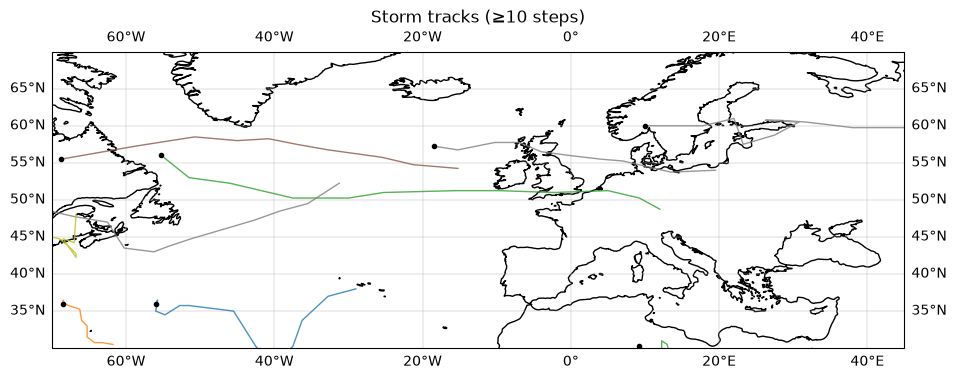

In [95]:
def split_at_dateline(lons, lats):
    """Insert NaNs where a track jumps across the 0/360 or ±180 seam."""
    lons = np.asarray(lons, dtype=float)
    lats = np.asarray(lats, dtype=float)
    jumps = np.where(np.abs(np.diff(lons)) > 180)[0] + 1
    return np.insert(lons, jumps, np.nan), np.insert(lats, jumps, np.nan)

min_len = 10  # drop short-lived features

fig = plt.figure(figsize=(11, 6))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0))
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=0.3)
ax.set_extent([dk_lat_long[1][0], dk_lat_long[1][1], dk_lat_long[0][0], dk_lat_long[0][1]], crs=ccrs.PlateCarree())

for track in tracks:
    if len(track) < min_len:
        continue
    lons, lats = split_at_dateline(track.lons, track.lats)
    ax.plot(lons, lats, transform=ccrs.PlateCarree(), lw=1, alpha=0.8)
    ax.plot(lons[0], lats[0], "o", ms=3, color="k", transform=ccrs.PlateCarree())  # genesis point

ax.set_title(f"Storm tracks (≥{min_len} steps)")
plt.savefig("tracks.png", dpi=150, bbox_inches="tight")
plt.show()

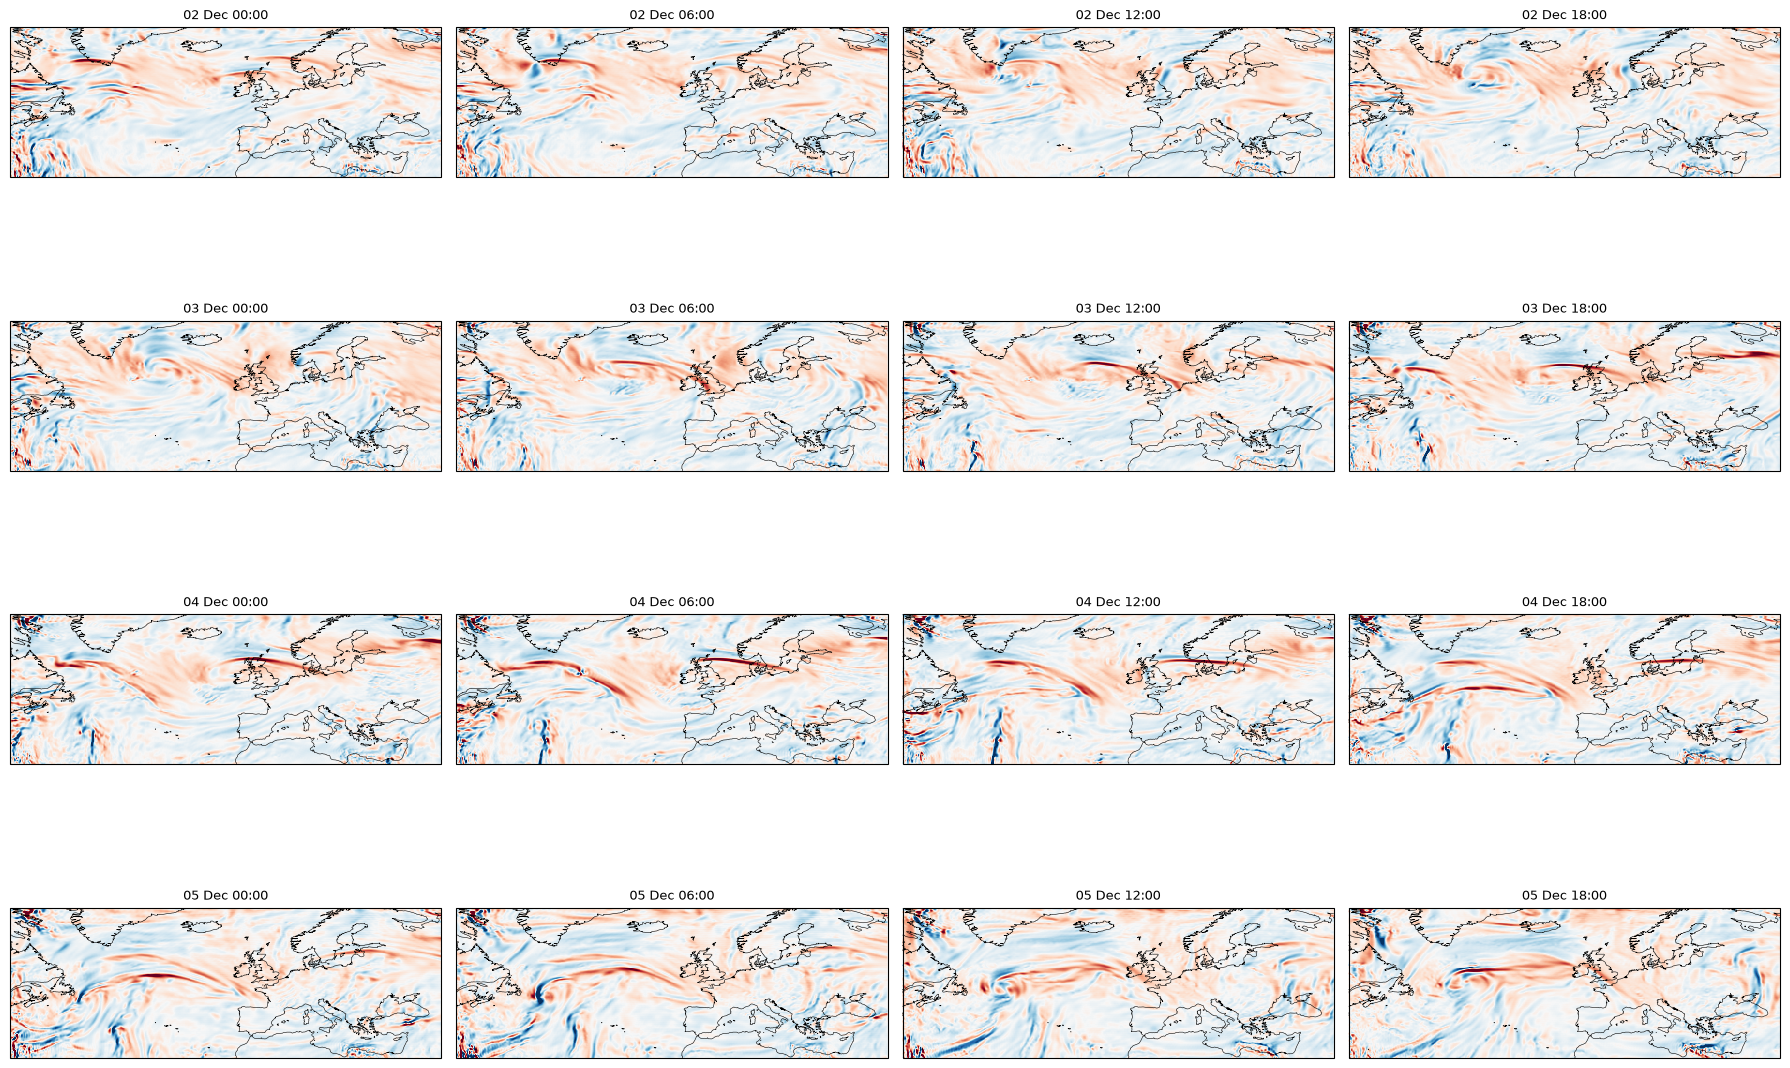

In [96]:
#plotting the vorticity field with the tracks overlayed

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd

times = pd.to_datetime(vor.time.values)
n = len(times)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(4.5 * ncols, 3.2 * nrows),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

vmax = float(np.abs(vor).quantile(0.995))   # shared color scale across panels

for i, (ax, t) in enumerate(zip(axes.flat, times)):
    field = vor.isel(time=i)
    ax.coastlines(linewidth=0.4)
    ax.pcolormesh(
        vor.longitude, vor.latitude, field,
        transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=-vmax, vmax=vmax,
    )
    ax.set_title(t.strftime("%d %b %H:%M"), fontsize=9)
    ax.set_extent([dk_lat_long[1][0], dk_lat_long[1][1], dk_lat_long[0][0], dk_lat_long[0][1]], crs=ccrs.PlateCarree())

    # overlay every track's point at this timestep, colored by track_id
    for tr in tracks:
        tr_times = pd.to_datetime(np.asarray(tr.times))
        match = np.where(tr_times == t)[0]
        if len(match):
            j = match[0]
            ax.plot(tr.lons[j], tr.lats[j], "o", ms=4, mec="k", mfc="yellow",
                     transform=ccrs.PlateCarree())
            ax.annotate(str(tr.track_id), (tr.lons[j], tr.lats[j]),
                        fontsize=6, xytext=(2, 2), textcoords="offset points")
            #ax.set_extent([dk_lat_long[1][0], dk_lat_long[1][1], dk_lat_long[0][0], dk_lat_long[0][1]], crs=ccrs.PlateCarree())

for ax in axes.flat[n:]:
    ax.axis("off")

fig.tight_layout()
#plt.savefig("vorticity_timeseries.png", dpi=130)

panel 0: 0 tracks plotted


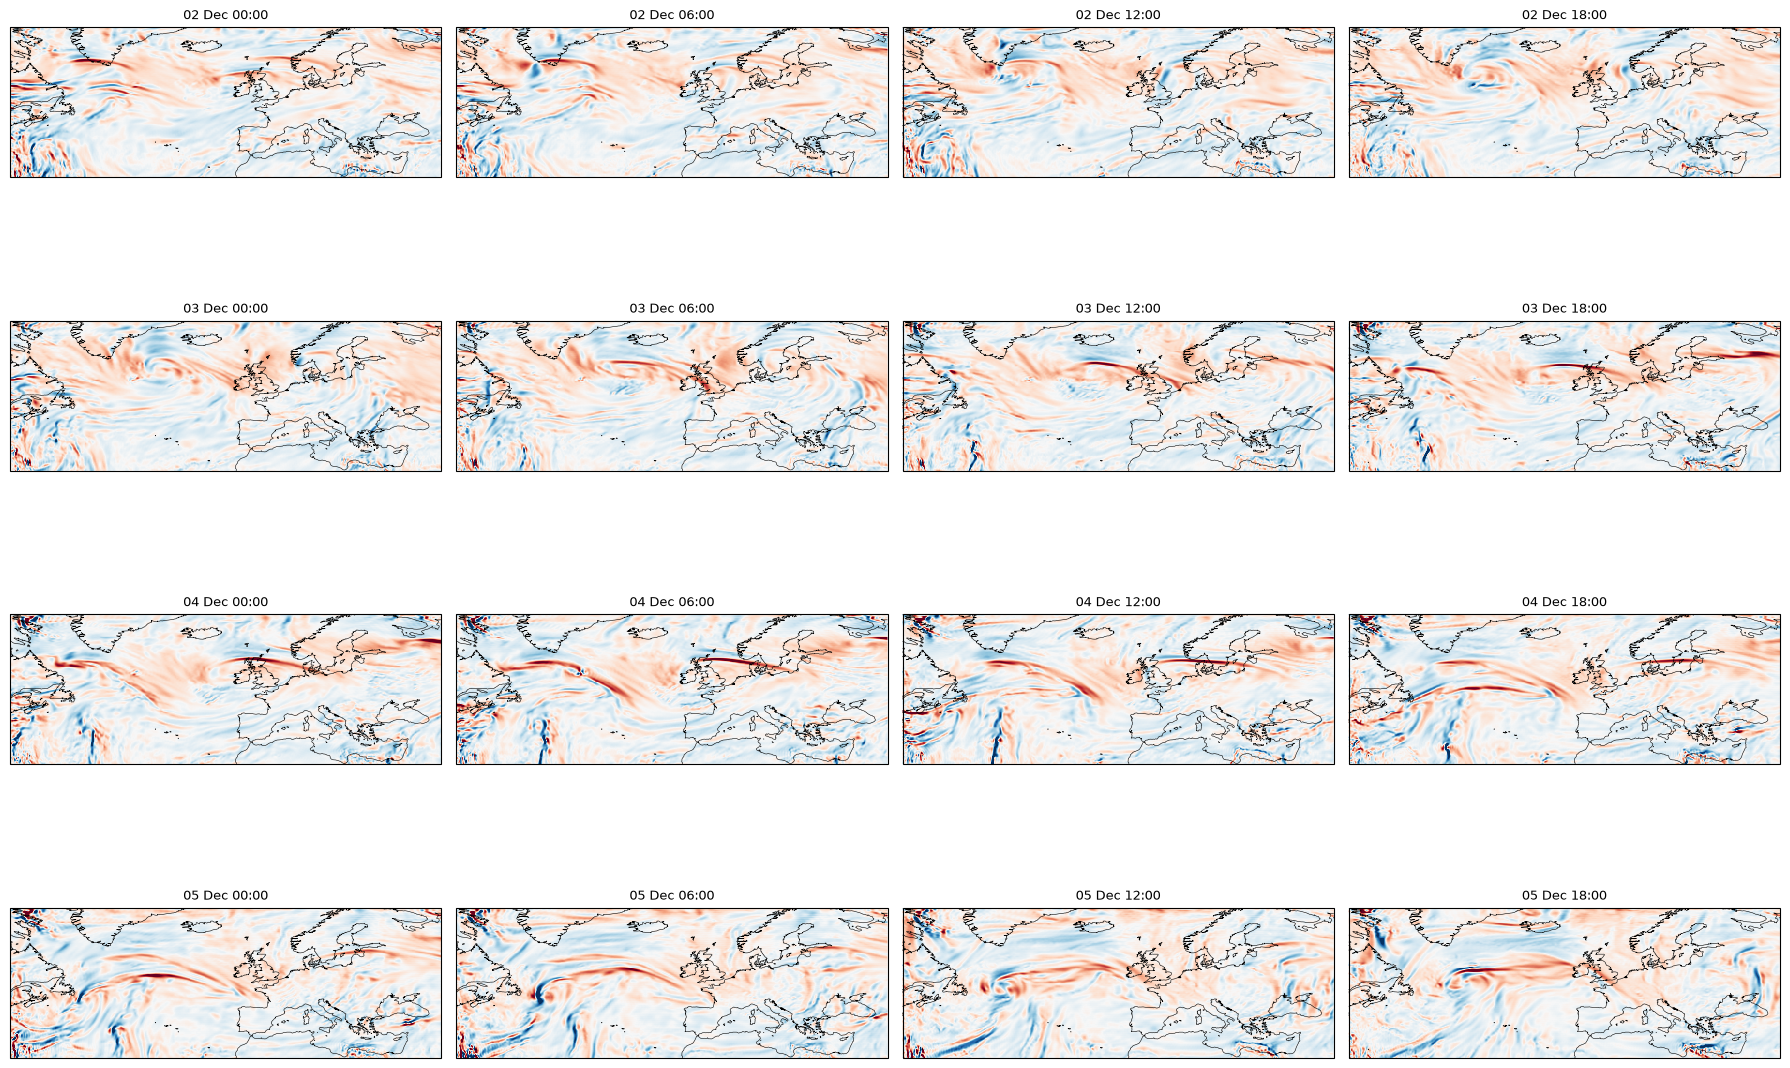

In [97]:

times = pd.to_datetime(vor.time.values)
n = len(times)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(4.5 * ncols, 3.2 * nrows),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

vmax = float(np.abs(vor).quantile(0.995))   # shared color scale across panels

for i, (ax, t) in enumerate(zip(axes.flat, times)):
    field = vor.isel(time=i)
    ax.coastlines(linewidth=0.4)
    ax.pcolormesh(
        vor.longitude, vor.latitude, field,
        transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=-vmax, vmax=vmax,
    )
    ax.set_title(t.strftime("%d %b %H:%M"), fontsize=9)
    ax.set_extent([dk_lat_long[1][0], dk_lat_long[1][1], dk_lat_long[0][0], dk_lat_long[0][1]], crs=ccrs.PlateCarree())

    n_plotted = 0
    for tr in tracks:
        tr_times = pd.to_datetime(np.asarray(tr.times), unit="ns").floor("h")
        match = np.where(tr_times == t.floor("h"))[0]
        if len(match):
            j = match[0]
            ax.plot(tr.lons[j], tr.lats[j], "o", ms=6, mec="k", mfc="yellow",
                     transform=ccrs.PlateCarree(), zorder=5)
            ax.annotate(str(tr.track_id), (tr.lons[j], tr.lats[j]),
                        fontsize=6, xytext=(2, 2), textcoords="offset points",
                        zorder=6)
            n_plotted += 1
    if i == 0:
        print(f"panel 0: {n_plotted} tracks plotted")

for ax in axes.flat[n:]:
    ax.axis("off")

fig.tight_layout()
#plt.savefig("vorticity_timeseries.png", dpi=130)

In [98]:
all_track_times = pd.to_datetime(np.concatenate([np.asarray(t.times) for t in tracks]), unit="ns")
overlap = np.isin(all_track_times, times)

print(f"{overlap.sum()} of {len(all_track_times)} track timestamps found in vor's times")
print(all_track_times[0], times[0])

0 of 1090 track timestamps found in vor's times
1970-01-01 00:15:44.092800 1999-12-02 00:00:00
